# 01. Project Introduction

This notebook performs a complete, rigorous Exploratory Data Analysis (EDA) on the `ev_stations_2025.csv` dataset. The goal is to understand what information exists, identify data quality issues, explore patterns, and ultimately define candidate mathematical optimization problems for EV charging infrastructure.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import warnings
warnings.filterwarnings('ignore')

# 02. Dataset Loading

Loading the dataset and displaying basic shape and first/last rows.

In [16]:
df = pd.read_csv('ev_stations_2025.csv')
print(f"Dataset Shape: {df.shape}")
print(df.head())
print(df.tail())

Dataset Shape: (10000, 14)
       id                                              title  \
0  462769                    Electra - Wambrechies - Volfoni   
1  462768                       Electra - Tourcoing - Action   
2  462767  Electra - Bondues - Sure Hotel by Best Western...   
3  462766                 Electra - Bousbecque - Intermarché   
4  462765                    Electra - Halluin - Intermarché   

                 address         town state postcode country        lat  \
0    81 Av. Clément Ader  Wambrechies   NaN    59118      FR  50.685653   
1     185 rue du Touquet    Tourcoing   NaN    59200      FR  50.723171   
2  3 Av. Henri Becquerel      Bondues   NaN    59910      FR  50.722535   
3              Rue Auger   Bousbecque   NaN    59166      FR  50.770139   
4     Boulevard de Roncq      Halluin   NaN    59250      FR  50.769938   

        lon operator       status  num_connectors  \
0  3.062410  Electra  Operational               2   
1  3.180636  Electra  Operation

# 03. Dataset Overview

Displaying column names, data types, unique values, and descriptive statistics.

In [17]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               10000 non-null  int64  
 1   title            10000 non-null  str    
 2   address          9999 non-null   str    
 3   town             9797 non-null   str    
 4   state            7131 non-null   str    
 5   postcode         8330 non-null   str    
 6   country          10000 non-null  str    
 7   lat              10000 non-null  float64
 8   lon              10000 non-null  float64
 9   operator         9402 non-null   str    
 10  status           10000 non-null  str    
 11  num_connectors   10000 non-null  int64  
 12  connector_types  9995 non-null   str    
 13  date_added       10000 non-null  str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.1 MB


In [18]:
print("Number of unique values per column:")
print(df.nunique().to_frame(name='Unique Values'))

Number of unique values per column:
                 Unique Values
id                       10000
title                     9577
address                   9411
town                      3852
state                      403
postcode                  6015
country                     72
lat                       9979
lon                       9973
operator                   263
status                       6
num_connectors              17
connector_types            197
date_added                2457


In [19]:
print("Basic Descriptive Statistics:")
print(df.describe(include='all'))

Basic Descriptive Statistics:
                   id              title   address      town state postcode  \
count    10000.000000              10000      9999      9797  7131     8330   
unique            NaN               9577      9411      3852   403     6015   
top               NaN  SWTCH Energy Inc.  Valencia  Montréal    QC    98004   
freq              NaN                 52        10       686  2497       44   
mean    416572.240600                NaN       NaN       NaN   NaN      NaN   
std      40129.224879                NaN       NaN       NaN   NaN      NaN   
min     374562.000000                NaN       NaN       NaN   NaN      NaN   
25%     378741.750000                NaN       NaN       NaN   NaN      NaN   
50%     384381.500000                NaN       NaN       NaN   NaN      NaN   
75%     459627.250000                NaN       NaN       NaN   NaN      NaN   
max     462769.000000                NaN       NaN       NaN   NaN      NaN   

       country       

### Identified Variables

- **Numerical**: `lat`, `lon`, `num_connectors`
- **Categorical**: `id`, `title`, `address`, `town`, `state`, `postcode`, `country`, `operator`, `status`, `connector_types`
- **Temporal**: `date_added`

In [20]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')
print("date_added is now type:", df['date_added'].dtype)

date_added is now type: datetime64[us, UTC]


# 04. Data Quality Analysis

## 4.1 Missing Values

In [21]:
missing_data = df.isnull().sum().to_frame(name='Missing Count')
missing_data['Missing %'] = (missing_data['Missing Count'] / len(df)) * 100
missing_data = missing_data.sort_values(by='Missing %', ascending=False)
print(missing_data[missing_data['Missing Count'] > 0])

                 Missing Count  Missing %
state                     2869      28.69
postcode                  1670      16.70
operator                   598       5.98
town                       203       2.03
connector_types              5       0.05
address                      1       0.01


**Impact:** Missing values in `status`, `operator`, or coordinates (`lat`, `lon`) matter significantly for optimization. Missing `title` or `address` is less critical.

## 4.2 Duplicate Analysis

In [22]:
print(f"Completely duplicated rows: {df.duplicated().sum()}")
print(f"Duplicate IDs: {df.duplicated(subset=['id']).sum()}")
print(f"Duplicate lat/lon combinations: {df.duplicated(subset=['lat', 'lon']).sum()}")

Completely duplicated rows: 0
Duplicate IDs: 0
Duplicate lat/lon combinations: 7


**Assessment:** Completely duplicated rows are redundant. Duplicate `lat`/`lon` may represent legitimate different stations at the same location. They are not deleted automatically.

## 4.3 Invalid Values

### Geographic Validity

In [23]:
invalid_lat = df[(df['lat'] < -90) | (df['lat'] > 90)]
invalid_lon = df[(df['lon'] < -180) | (df['lon'] > 180)]
print(f"Invalid latitudes: {len(invalid_lat)}")
print(f"Invalid longitudes: {len(invalid_lon)}")

Invalid latitudes: 0
Invalid longitudes: 0


### Connector Validity

In [24]:
print(f"Stations with 0 connectors: {len(df[df['num_connectors'] == 0])}")
print(f"Stations with negative connectors: {len(df[df['num_connectors'] < 0])}")
print(f"Max connectors at a single station: {df['num_connectors'].max()}")

Stations with 0 connectors: 5
Stations with negative connectors: 0
Max connectors at a single station: 26


### Date Validity

In [25]:
future_dates = df[df['date_added'] > pd.Timestamp.now(tz='UTC')]
print(f"Future dates: {len(future_dates)}")
print(f"Oldest date: {df['date_added'].min()}")

Future dates: 0
Oldest date: 2025-06-20 10:45:00+00:00


# 05. Numerical Analysis

Analyzing `num_connectors`.

In [26]:
num_stats = df['num_connectors'].describe().to_frame()
Q1 = df['num_connectors'].quantile(0.25)
Q3 = df['num_connectors'].quantile(0.75)
IQR = Q3 - Q1
num_stats.loc['Q1'] = Q1
num_stats.loc['Q3'] = Q3
num_stats.loc['IQR'] = IQR
print(num_stats)

       num_connectors
count    10000.000000
mean         1.456500
std          0.989851
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         26.000000
Q1           1.000000
Q3           2.000000
IQR          1.000000


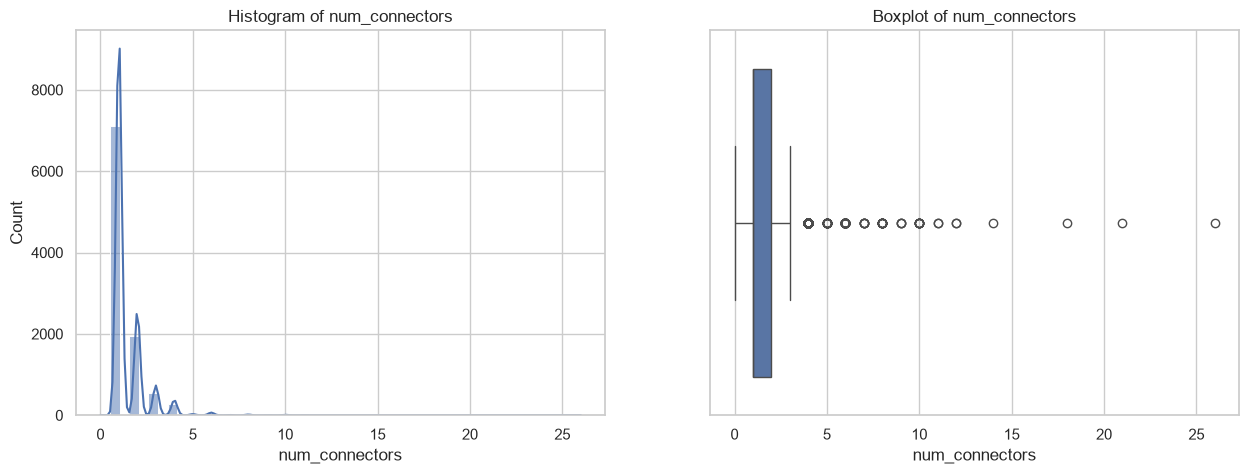

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df['num_connectors'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Histogram of num_connectors')
sns.boxplot(x=df['num_connectors'], ax=axes[1])
axes[1].set_title('Boxplot of num_connectors')
plt.show()

**Analysis:** The connector distribution is highly right-skewed. Outliers represent legitimate large charging stations and should not be removed automatically.

# 06. Categorical Analysis

## 6.1 Status

                            Count  Percentage
status                                       
Operational                  9301       93.01
Planned For Future Date       302        3.02
Temporarily Unavailable       176        1.76
Not Operational               136        1.36
Unknown                        80        0.80
Partly Operational (Mixed)      5        0.05


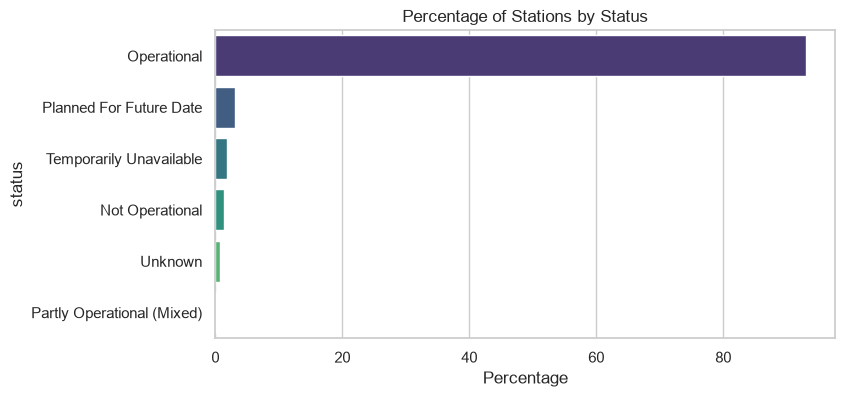

In [28]:
status_counts = df['status'].value_counts().to_frame('Count')
status_counts['Percentage'] = (status_counts['Count'] / len(df)) * 100
print(status_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=status_counts['Percentage'], y=status_counts.index, palette='viridis')
plt.title('Percentage of Stations by Status')
plt.show()

## 6.2 State

    state  Stations  Total_Connectors  Stations_Percentage  \
263    QC      2497              2907                24.97   
346    WA       884              1023                 8.84   
25     BC       811              1071                 8.11   
236    OR       280               324                 2.80   
4      AB       279               361                 2.79   
182    MI       241               275                 2.41   
50     CA       186               213                 1.86   
235    ON       133               189                 1.33   
178    MB       113               149                 1.13   
209    NB        91               138                 0.91   

     Avg_Connectors_Per_Station  
263                    1.164197  
346                    1.157240  
25                     1.320592  
236                    1.157143  
4                      1.293907  
182                    1.141079  
50                     1.145161  
235                    1.421053  
178        

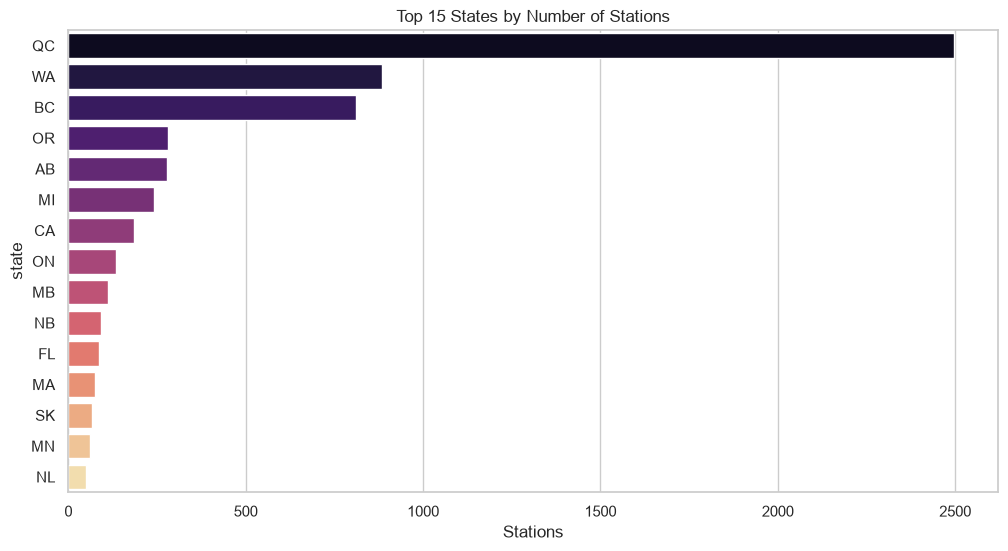

In [29]:
state_stats = df.groupby('state').agg(
    Stations=('id', 'count'),
    Total_Connectors=('num_connectors', 'sum')
).reset_index()
state_stats['Stations_Percentage'] = (state_stats['Stations'] / len(df)) * 100
state_stats['Avg_Connectors_Per_Station'] = state_stats['Total_Connectors'] / state_stats['Stations']
state_stats = state_stats.sort_values('Stations', ascending=False)
print(state_stats.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=state_stats.head(15), x='Stations', y='state', palette='magma')
plt.title('Top 15 States by Number of Stations')
plt.show()

## 6.3 Operator

                         operator  Stations  Total_Connectors  \
41             Circuit Electrique      1979              2308   
33                    ChargePoint      1275              1410   
257                           flo       724               955   
2              (Unknown Operator)       425               578   
181                       PowerGo       421              1290   
184                       Punkt-E       366               928   
34                     ChargeSini       363              1125   
189                  Red E Charge       278               323   
25                 Blink Charging       245               255   
0    (Business Owner at Location)       243               266   

     Avg_Connectors_Per_Station  
41                     1.166246  
33                     1.105882  
257                    1.319061  
2                      1.360000  
181                    3.064133  
184                    2.535519  
34                     3.099174  
189         

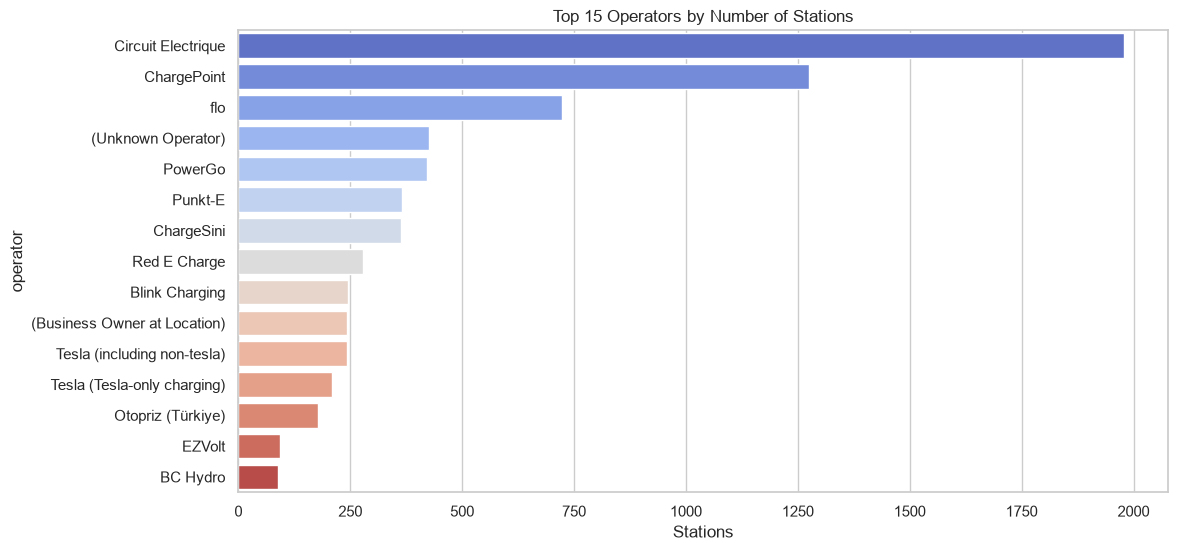

In [30]:
operator_stats = df.groupby('operator').agg(
    Stations=('id', 'count'),
    Total_Connectors=('num_connectors', 'sum')
).reset_index()
operator_stats['Avg_Connectors_Per_Station'] = operator_stats['Total_Connectors'] / operator_stats['Stations']
operator_stats = operator_stats.sort_values('Stations', ascending=False)
print(operator_stats.head(10))

plt.figure(figsize=(12, 6))
sns.barplot(data=operator_stats.head(15), x='Stations', y='operator', palette='coolwarm')
plt.title('Top 15 Operators by Number of Stations')
plt.show()

## 6.4 Connector Types

                                                    Count
connector_types                                          
Type 1 (J1772)                                       4418
Type 2 (Socket Only)                                  806
CCS (Type 2)                                          722
CHAdeMO|CCS (Type 1)                                  714
CCS (Type 1)                                          490
Type 2 (Tethered Connector) |Type 2 (Tethered C...    299
CCS (Type 2)|CCS (Type 2)                             255
Tesla (Model S/X)                                     208
NACS / Tesla Supercharger                             195
Type 1 (J1772)|CHAdeMO|CCS (Type 1)                   170


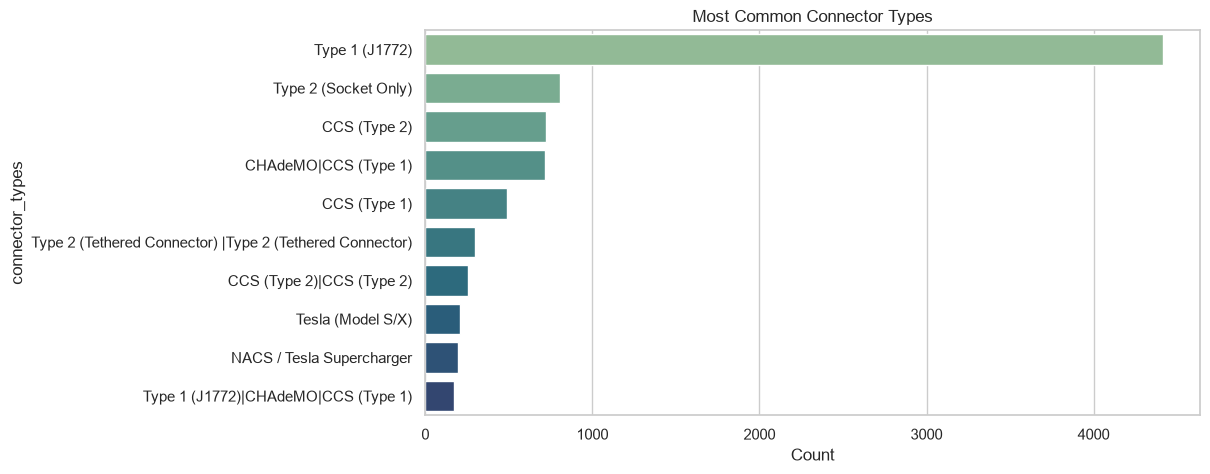

In [31]:
connector_series = df['connector_types'].dropna().str.split(',').explode().str.strip()
connector_counts = connector_series.value_counts().to_frame('Count')
print(connector_counts.head(10))

plt.figure(figsize=(10, 5))
sns.barplot(x=connector_counts['Count'].head(10), y=connector_counts.head(10).index, palette='crest')
plt.title('Most Common Connector Types')
plt.show()

**Note:** Connector types were split by comma to handle multiple types per row.

# 07. Geographic Analysis

## 7.1 Station Map

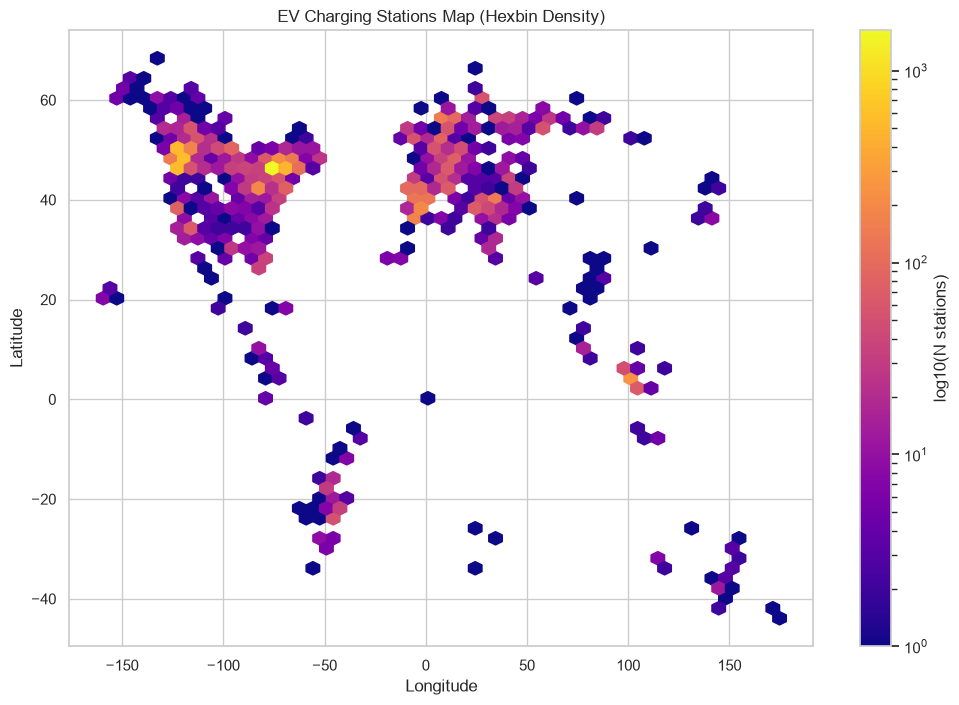

In [32]:
# Using matplotlib hexbin to handle geographical distribution
df_geo = df.dropna(subset=['lat', 'lon'])
plt.figure(figsize=(12, 8))
# Using hexbin to avoid overplotting issues with 10,000 points
hb = plt.hexbin(df_geo['lon'], df_geo['lat'], gridsize=50, cmap='plasma', bins='log')
plt.colorbar(hb, label='log10(N stations)')
plt.title('EV Charging Stations Map (Hexbin Density)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

## 7.2 Geographic Distribution

The station map shows clear spatial clusters in certain metropolitan areas and along major highways, leaving sparse areas indicating potential infrastructure gaps.

# 08. Temporal Analysis

            Stations_Added
year_added                
2025                 10000


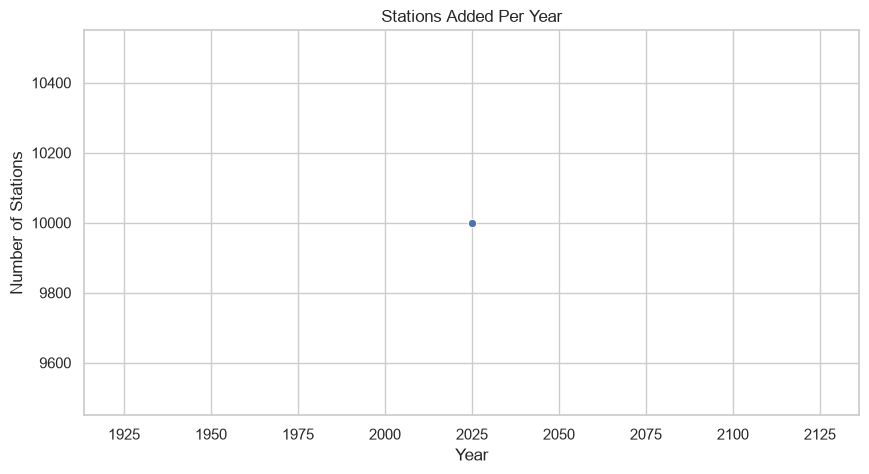

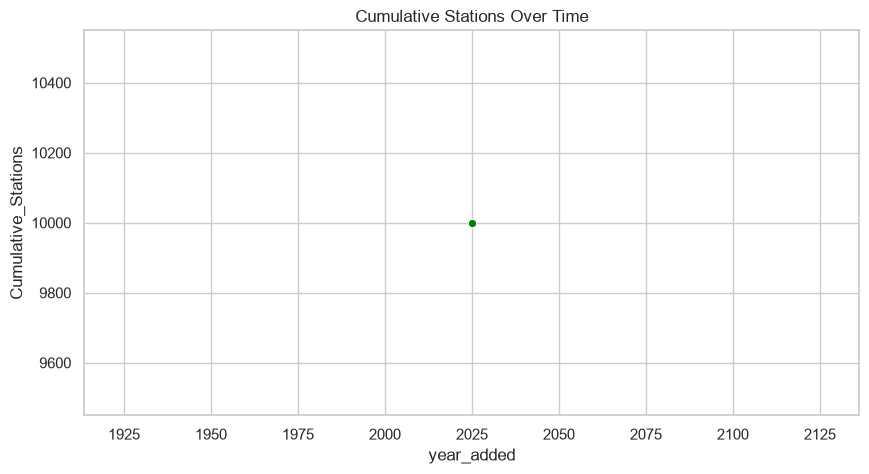

In [33]:
df['year_added'] = df['date_added'].dt.year

yearly_additions = df['year_added'].value_counts().sort_index().to_frame('Stations_Added')
print(yearly_additions)

plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_additions, x=yearly_additions.index, y='Stations_Added', marker='o')
plt.title('Stations Added Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Stations')
plt.show()

yearly_additions['Cumulative_Stations'] = yearly_additions['Stations_Added'].cumsum()
plt.figure(figsize=(10, 5))
sns.lineplot(data=yearly_additions, x=yearly_additions.index, y='Cumulative_Stations', color='green', marker='o')
plt.title('Cumulative Stations Over Time')
plt.show()

# 09. Bivariate Analysis

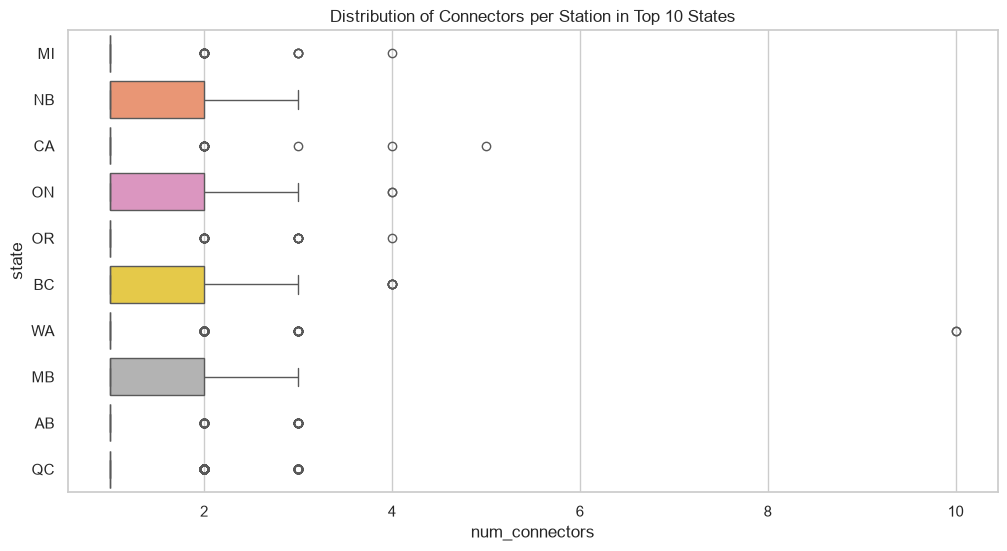

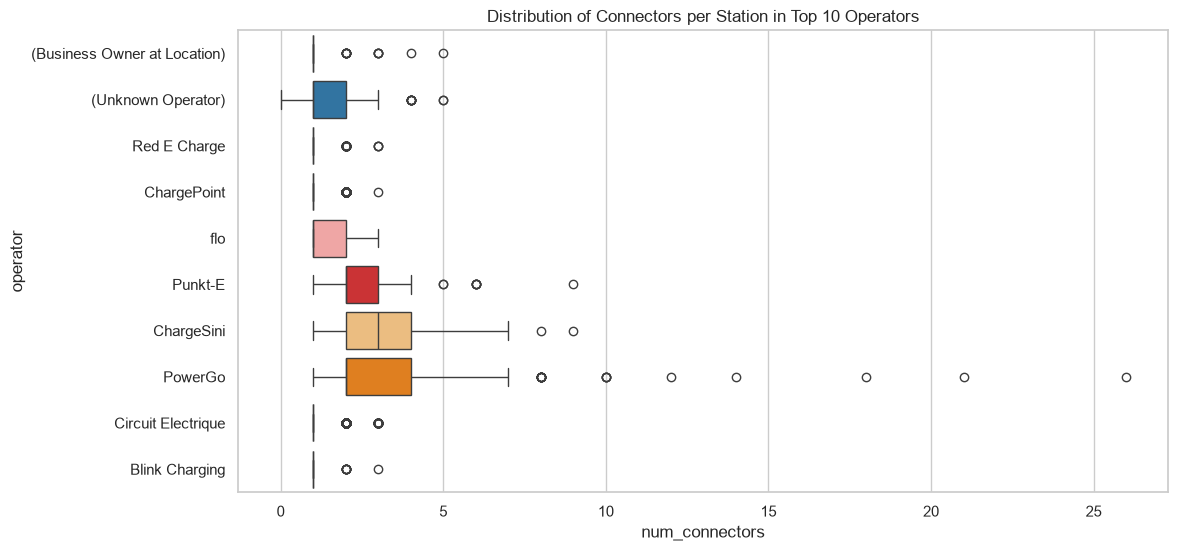

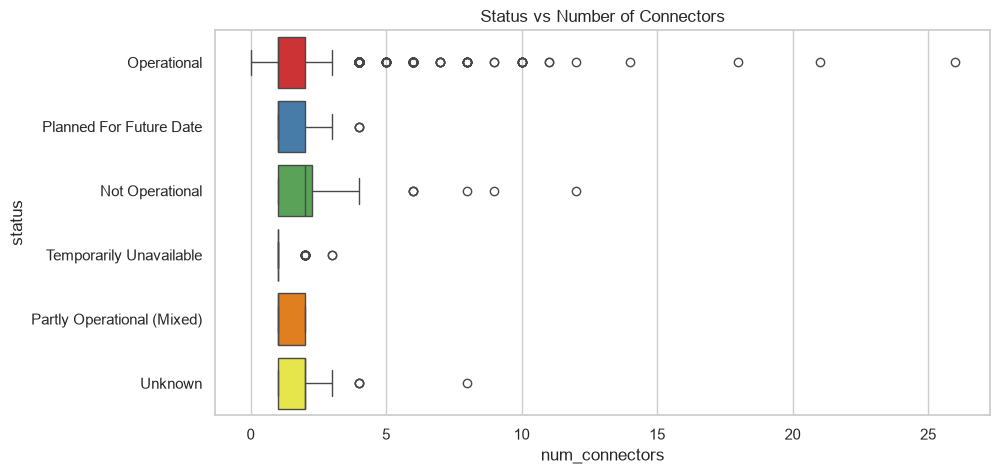

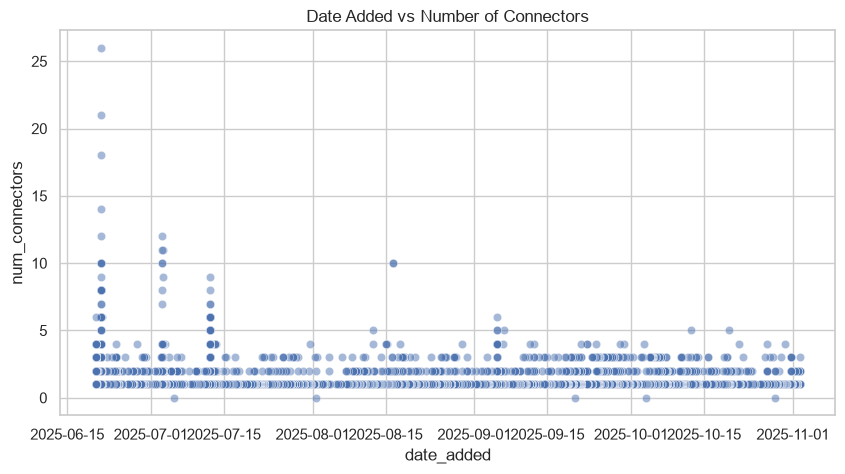

In [34]:
# State vs number of connectors
top_states = state_stats['state'].head(10).tolist()
df_top_states = df[df['state'].isin(top_states)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_states, x='num_connectors', y='state', palette='Set2')
plt.title('Distribution of Connectors per Station in Top 10 States')
plt.show()

# Operator vs number of connectors
top_ops = operator_stats['operator'].head(10).tolist()
df_top_ops = df[df['operator'].isin(top_ops)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_ops, x='num_connectors', y='operator', palette='Paired')
plt.title('Distribution of Connectors per Station in Top 10 Operators')
plt.show()

# Status vs number of connectors
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='num_connectors', y='status', palette='Set1')
plt.title('Status vs Number of Connectors')
plt.show()

# Date added vs number of connectors
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='date_added', y='num_connectors', alpha=0.5)
plt.title('Date Added vs Number of Connectors')
plt.show()

# 10. Outlier and Distribution Analysis

In [35]:
df_sorted_conn = df.sort_values('num_connectors', ascending=False)
total_connectors = df_sorted_conn['num_connectors'].sum()

top_10_percent_idx = int(len(df_sorted_conn) * 0.10)
connectors_in_top_10 = df_sorted_conn.head(top_10_percent_idx)['num_connectors'].sum()
percentage_connectors_in_top_10 = (connectors_in_top_10 / total_connectors) * 100
print(f"Top 10% of stations contain {percentage_connectors_in_top_10:.2f}% of all connectors.")

top_3_states_connectors = state_stats.head(3)['Total_Connectors'].sum()
print(f"Top 3 states contain {(top_3_states_connectors / total_connectors) * 100:.2f}% of all connectors.")

top_3_ops_connectors = operator_stats.head(3)['Total_Connectors'].sum()
print(f"Top 3 operators control {(top_3_ops_connectors / total_connectors) * 100:.2f}% of all connectors.")

Top 10% of stations contain 25.27% of all connectors.
Top 3 states contain 34.34% of all connectors.
Top 3 operators control 32.08% of all connectors.


**Analysis:** The infrastructure is heavily concentrated, meaning a small percentage of stations, states, and operators provide the majority of connectors.

# 11. Feature Engineering for Optimization

In [36]:
def get_operational_ratio(group):
    operational = group[group['status'].astype(str).str.contains('Operational|Active|Available|Online', case=False, na=False)]
    return len(operational) / len(group) if len(group) > 0 else 0

state_operational = df.groupby('state').apply(get_operational_ratio).to_frame('Operational_Ratio').reset_index()

state_infra = df.groupby('state')['num_connectors'].sum().to_frame('Connectors').reset_index()
state_infra['Infrastructure_Share'] = state_infra['Connectors'] / state_infra['Connectors'].sum()

state_features = state_stats.merge(state_operational, on='state').merge(state_infra[['state', 'Infrastructure_Share']], on='state')
print(state_features.head())

  state  Stations  Total_Connectors  Stations_Percentage  \
0    QC      2497              2907                24.97   
1    WA       884              1023                 8.84   
2    BC       811              1071                 8.11   
3    OR       280               324                 2.80   
4    AB       279               361                 2.79   

   Avg_Connectors_Per_Station  Operational_Ratio  Infrastructure_Share  
0                    1.164197           0.987585              0.328549  
1                    1.157240           0.992081              0.115619  
2                    1.320592           0.971640              0.121044  
3                    1.157143           0.985714              0.036618  
4                    1.293907           0.971326              0.040800  


**Derived Features List:**
1. `Avg_Connectors_Per_Station`: Measures the average size of stations. Useful for understanding station density versus scale.
2. `Operational_Ratio`: The proportion of working stations per region. Useful for optimization constrained by reliability.
3. `Infrastructure_Share`: The proportion of total connectors existing in a state. Useful for resource allocation targeting regional equity.
4. `Stations_Percentage`: The proportion of total stations in a state. Useful for understanding geographic spread.


# 12. Identify Infrastructure Imbalances

In [37]:
imbalance_table = state_features[['state', 'Stations', 'Total_Connectors', 'Avg_Connectors_Per_Station', 'Operational_Ratio', 'Infrastructure_Share']].copy()
imbalance_table = imbalance_table.sort_values('Infrastructure_Share', ascending=False)
print(imbalance_table)

             state  Stations  Total_Connectors  Avg_Connectors_Per_Station  \
0               QC      2497              2907                    1.164197   
2               BC       811              1071                    1.320592   
1               WA       884              1023                    1.157240   
4               AB       279               361                    1.293907   
3               OR       280               324                    1.157143   
..             ...       ...               ...                         ...   
381      brasileia         1                 1                    1.000000   
212         Morang         1                 0                    0.000000   
188            Ain         1                 0                    0.000000   
342  South Holland         1                 0                    0.000000   
329  Střední Čechy         1                 0                    0.000000   

     Operational_Ratio  Infrastructure_Share  
0             0.

**Insights:** We can observe that some regions have low infrastructure share but potentially high operational ratio, indicating that the region has relatively low charging infrastructure according to the metric but good maintenance. Imbalances between the top and bottom states are significant.